In [9]:
import yaml
import supervision as sv
import os


### Changing the labels to match

In [10]:

#Need to change all the .yaml classes to match


#Get the class names from one of the datasets
with open("../chess pieces.v3i.yolov11/data.yaml", "r") as f:
    config_1 = yaml.safe_load(f)

classes = config_1["names"]



In [11]:
classes

['BB', 'BK', 'BKN', 'BP', 'BQ', 'BR', 'WB', 'WK', 'WKN', 'WP', 'WQ', 'WR']

In [12]:
#Dataset2
with open("../chess.v2i.yolov11/data.yaml", "r") as f:
    config_2 = yaml.safe_load(f)

config_2["names"] = classes

with open("../chess.v2i.yolov11/data.yaml", "w") as f:
    yaml.dump(config_2,f,default_flow_style=False)


#Dataset3
with open("../Chess.v3i.yolov11/data.yaml", "r") as f:
    config_3 = yaml.safe_load(f)

config_3["names"] = classes

with open("../chess.v3i.yolov11/data.yaml", "w") as f:
    yaml.dump(config_3,f,default_flow_style=False)


In [13]:
config_2["names"]

['BB', 'BK', 'BKN', 'BP', 'BQ', 'BR', 'WB', 'WK', 'WKN', 'WP', 'WQ', 'WR']

### Merge the datasets

In [14]:

dst_folder = "../merged_dataset"
dataset_location_1 = "../chess pieces.v3i.yolov11"
dataset_location_2 = "../chess.v2i.yolov11"
dataset_location_3 = "../chess.v3i.yolov11"



os.makedirs(dst_folder,exist_ok=True)
dataset_names = ["train","test","valid"]



for dataset_name in dataset_names: #For the different data folders open, merge and save
    dataset_1 = sv.DetectionDataset.from_yolo(
        images_directory_path = f"{dataset_location_1}/{dataset_name}/images",
        annotations_directory_path = f"{dataset_location_1}/{dataset_name}/labels",
        data_yaml_path = f"{dataset_location_1}/data.yaml"
    )
    dataset_2 = sv.DetectionDataset.from_yolo(
        images_directory_path = f"{dataset_location_2}/{dataset_name}/images",
        annotations_directory_path = f"{dataset_location_2}/{dataset_name}/labels",
        data_yaml_path = f"{dataset_location_2}/data.yaml"
    )

    for i in range(len(dataset_2)):

        dataset_2[i][2].class_id = [(int(label)+6) % 12 for label in dataset_2[i][2].class_id] #dataset 2 has wrong labels, this fixes it
    
    


    dataset_3 = sv.DetectionDataset.from_yolo(
        images_directory_path = f"{dataset_location_3}/{dataset_name}/images",
        annotations_directory_path = f"{dataset_location_3}/{dataset_name}/labels",
        data_yaml_path = f"{dataset_location_3}/data.yaml"
    )

    merged_ds = sv.DetectionDataset.merge([dataset_1,dataset_2,dataset_3])

    os.makedirs(f"{dst_folder}/{dataset_name}/images", exist_ok=True)
    os.makedirs(f"{dst_folder}/{dataset_name}/labels", exist_ok=True)


    merged_ds.as_yolo(
        images_directory_path = f"{dst_folder}/{dataset_name}/images",
        annotations_directory_path = f"{dst_folder}/{dataset_name}/labels",



    )


#Create the final yaml file 
final_yaml = {
    "train": f"{dst_folder}/train/images",
    "val": f"{dst_folder}/valid/images",
    "test": f"{dst_folder}/test/images",
    "nc": len(merged_ds.classes),
    "names": merged_ds.classes
}

with open(f"{dst_folder}/data.yaml", "w") as f:
    yaml.dump(final_yaml, f, default_flow_style=False, sort_keys=False)

### Merge the custom dataset with the previously merged dataset

In [15]:
os.listdir()

['captured_images',
 'merge_piece_datasets.ipynb',
 'runs',
 'take_images.ipynb',
 'Train_pieces_model.ipynb',
 'yolo26n.pt',
 'yolo26s.pt']

In [16]:
dataset_1_path = "../merged_dataset"
dataset_2_path = "../project-6-at-2026-02-25-17-06-87cd7413"

#Train dataset
dataset_merged_train = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset_1_path}/train/images",
    annotations_directory_path=f"{dataset_1_path}/train/labels",
    data_yaml_path=f"{dataset_1_path}/data.yaml"
)

dataset_merged_test = sv.DetectionDataset.from_yolo( #We don't need a separate test dataset so might as well use it
    images_directory_path=f"{dataset_1_path}/test/images",
    annotations_directory_path=f"{dataset_1_path}/test/labels",
    data_yaml_path=f"{dataset_1_path}/data.yaml"
)

dataset_custom_train = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset_2_path}/train/images",
    annotations_directory_path=f"{dataset_2_path}/train/labels",
    data_yaml_path=f"{dataset_2_path}/data.yaml"
)

merged_train = sv.DetectionDataset.merge([dataset_custom_train,dataset_merged_train,dataset_merged_test])

In [17]:
os.makedirs("../final_data_folder",exist_ok=True)

merged_train.as_yolo(
    images_directory_path = f"../final_data_folder/train/images",
    annotations_directory_path = f"../final_data_folder/train/labels",
)

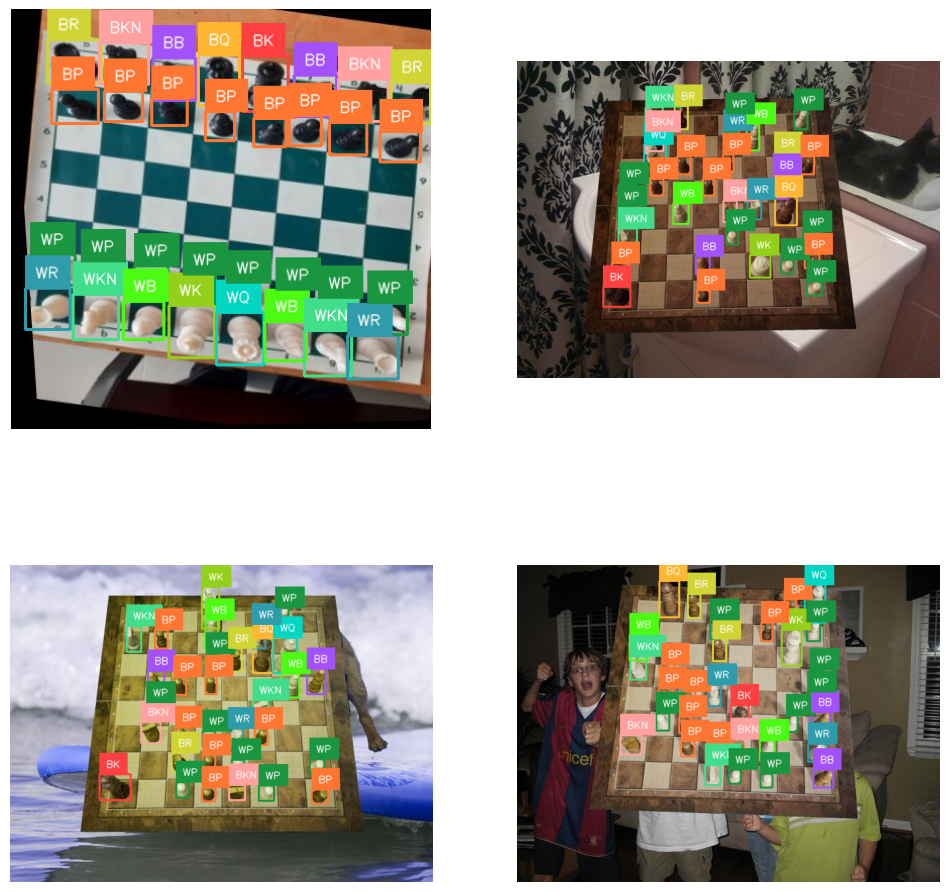

In [25]:
import numpy.random as npr

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_images = []
for i in range(4):

    random_index = npr.randint(0,len(merged_train))
    _, image, annotations = merged_train[random_index]

    labels = [merged_train.classes[class_id] for class_id in annotations.class_id]

    annotated_image = image.copy()
    annotated_image = box_annotator.annotate(annotated_image, annotations)
    annotated_image = label_annotator.annotate(annotated_image, annotations, labels)
    annotated_images.append(annotated_image)

sv.plot_images_grid(
    annotated_images,
    grid_size=(2, 2),
)

In [26]:
dataset_merged_valid = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset_1_path}/valid/images",
    annotations_directory_path=f"{dataset_1_path}/valid/labels",
    data_yaml_path=f"{dataset_1_path}/data.yaml"
)


dataset_custom_valid = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset_2_path}/valid/images",
    annotations_directory_path=f"{dataset_2_path}/valid/labels",
    data_yaml_path=f"{dataset_2_path}/data.yaml"
)


In [ ]:

merged_valid = sv.DetectionDataset.merge([dataset_custom_valid,dataset_merged_valid])

merged_valid.as_yolo(
    images_directory_path = f"../final_data_folder/valid/images",
    annotations_directory_path = f"../final_data_folder/valid/labels",
)